# 12_resnet18_transformer

Unified ResNet18 + Transformer compression experiment.

## Main idea
For each training compression level:
- build short temporal clips from that level's train split
- train on that level's train split
- validate on that level's val split
- save the best checkpoint
- test on all compression levels

## Compression levels
- orig
- CRF18
- CRF23
- CRF28
- CRF35
- CRF51

## Model
- ResNet18 frame encoder
- Transformer encoder for temporal modeling
- clip-level classification using the last token representation

## Outputs
Saved under:
- `cholec80/outputs/resnet18_transformer/checkpoints/`
- `cholec80/outputs/resnet18_transformer/predictions/`
- `cholec80/outputs/resnet18_transformer/metrics/`
- `cholec80/outputs/resnet18_transformer/plots/`
- `cholec80/outputs/resnet18_transformer/gradcam/`

In [1]:
# ============================================================
# 1. Imports
# ============================================================
import json
import math
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from tqdm.auto import tqdm

In [2]:
# ============================================================
# 2. Reproducibility and device
# ============================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        try:
            torch.mps.manual_seed(seed)
        except Exception:
            pass

set_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


In [3]:
# ============================================================
# 3. Paths
# ============================================================
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "cholec80"
FRAME_PREP_DIR = DATA_ROOT / "outputs" / "frame_prep"

MODEL_OUT_DIR = DATA_ROOT / "outputs" / "resnet18_transformer"
CHECKPOINT_DIR = MODEL_OUT_DIR / "checkpoints"
PREDICTIONS_DIR = MODEL_OUT_DIR / "predictions"
METRICS_DIR = MODEL_OUT_DIR / "metrics"
PLOTS_DIR = MODEL_OUT_DIR / "plots"
GRADCAM_DIR = MODEL_OUT_DIR / "gradcam"

for p in [CHECKPOINT_DIR, PREDICTIONS_DIR, METRICS_DIR, PLOTS_DIR, GRADCAM_DIR]:
    p.mkdir(parents=True, exist_ok=True)

METADATA_PATHS = {
    "orig": FRAME_PREP_DIR / "pilot_metadata_orig.csv",
    "CRF18": FRAME_PREP_DIR / "pilot_metadata_CRF18.csv",
    "CRF23": FRAME_PREP_DIR / "pilot_metadata_CRF23.csv",
    "CRF28": FRAME_PREP_DIR / "pilot_metadata_CRF28.csv",
    "CRF35": FRAME_PREP_DIR / "pilot_metadata_CRF35.csv",
    "CRF51": FRAME_PREP_DIR / "pilot_metadata_CRF51.csv",
}

In [4]:
# ============================================================
# 4. Config
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 5e-4
DROPOUT_P = 0.3

CLIP_LEN = 8
FRAME_STRIDE = 1

TRANSFORMER_DIM = 256
TRANSFORMER_HEADS = 4
TRANSFORMER_LAYERS = 2
TRANSFORMER_FF_DIM = 512

PHASE_MAP = {
    "Preparation": 0,
    "CalotTriangleDissection": 1,
    "ClippingCutting": 2,
    "GallbladderDissection": 3,
    "GallbladderPackaging": 4,
    "CleaningCoagulation": 5,
    "GallbladderRetraction": 6,
}
ID_TO_PHASE = {v: k for k, v in PHASE_MAP.items()}
NUM_CLASSES = len(PHASE_MAP)

LEVELS = ["orig", "CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]
CRF_X = [0, 18, 23, 28, 35, 51]
LEVEL_TO_X = dict(zip(LEVELS, CRF_X))

In [5]:
# ============================================================
# 5. Load metadata
# ============================================================
metadata = {}

for level, path in METADATA_PATHS.items():
    df = pd.read_csv(path)
    df = df[df["image_exists"] == True].copy().reset_index(drop=True)
    metadata[level] = df
    print(level, df.shape)

orig (46099, 9)
CRF18 (46099, 9)
CRF23 (46099, 9)
CRF28 (46099, 9)
CRF35 (46099, 9)
CRF51 (46099, 9)


In [6]:
# ============================================================
# 6. Transforms
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

## Build temporal clips

Each sample is a causal clip ending at a center frame:
- length = `CLIP_LEN`
- stride = `FRAME_STRIDE`
- label = phase at the center / last frame

In [7]:
# ============================================================
# 7. Build sequence samples
# ============================================================
def build_sequence_samples(df, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE):
    seq_rows = []

    for video, group in df.groupby("video"):
        group = group.sort_values("second_idx").reset_index(drop=True)
        by_second = {int(r["second_idx"]): r for _, r in group.iterrows()}

        valid_seconds = sorted(by_second.keys())

        for center_second in valid_seconds:
            start_second = center_second - (clip_len - 1) * frame_stride
            clip_seconds = [start_second + k * frame_stride for k in range(clip_len)]

            if not all(s in by_second for s in clip_seconds):
                continue

            clip_rows = [by_second[s] for s in clip_seconds]
            center_row = by_second[center_second]

            seq_rows.append({
                "compression": center_row["compression"],
                "video": center_row["video"],
                "split": center_row["split"],
                "center_second_idx": int(center_row["second_idx"]),
                "center_frame_idx": int(center_row["frame_idx"]),
                "phase_name": center_row["phase_name"],
                "phase_id": int(center_row["phase_id"]),
                "clip_image_paths": [r["image_path"] for r in clip_rows],
                "clip_second_idxs": clip_seconds,
                "center_image_path": center_row["image_path"],
            })

    return pd.DataFrame(seq_rows)

In [8]:
# ============================================================
# 8. Sequence dataset
# ============================================================
class CholecSequenceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = []
        for p in row["clip_image_paths"]:
            img = Image.open(p).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
            frames.append(img)

        frames = torch.stack(frames, dim=0)  # [T, C, H, W]
        label = int(row["phase_id"])

        meta = {
            "compression": row["compression"],
            "video": row["video"],
            "split": row["split"],
            "center_second_idx": int(row["center_second_idx"]),
            "center_frame_idx": int(row["center_frame_idx"]),
            "phase_name": row["phase_name"],
            "center_image_path": row["center_image_path"],
        }

        return frames, label, meta

In [9]:
# ============================================================
# 9. DataLoader builder
# ============================================================
def make_loaders_for_train_level(train_level):
    train_base = metadata[train_level][metadata[train_level]["split"] == "train"].reset_index(drop=True)
    val_base = metadata[train_level][metadata[train_level]["split"] == "val"].reset_index(drop=True)

    train_df = build_sequence_samples(train_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)
    val_df = build_sequence_samples(val_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)

    class_counts = train_df["phase_id"].value_counts().sort_index().to_dict()
    weights_per_class = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = train_df["phase_id"].map(weights_per_class).values

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        CholecSequenceDataset(train_df, transform=train_tfms),
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    val_loader = DataLoader(
        CholecSequenceDataset(val_df, transform=eval_tfms),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    test_loaders = {}
    test_sequence_dfs = {}

    for test_level in LEVELS:
        test_base = metadata[test_level][metadata[test_level]["split"] == "test"].reset_index(drop=True)
        test_df = build_sequence_samples(test_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)
        test_sequence_dfs[test_level] = test_df

        test_loaders[test_level] = DataLoader(
            CholecSequenceDataset(test_df, transform=eval_tfms),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=False,
        )

    return train_df, val_df, train_loader, val_loader, test_sequence_dfs, test_loaders

In [10]:
# ============================================================
# 10. Sanity check one train level
# ============================================================
train_df_check, val_df_check, *_ = make_loaders_for_train_level("orig")
print("orig train sequences:", train_df_check.shape)
print("orig val sequences:", val_df_check.shape)
train_df_check.head()

orig train sequences: (26886, 10)
orig val sequences: (9027, 10)


,compression,video,split,center_second_idx,center_frame_idx,phase_name,phase_id,clip_image_paths,clip_second_idxs,center_image_path
0,orig,video01,train,7,175,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[0, 1, 2, 3, 4, 5, 6, 7]",/Users/niranjani/Desktop/video-compression-pro...
1,orig,video01,train,8,200,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[1, 2, 3, 4, 5, 6, 7, 8]",/Users/niranjani/Desktop/video-compression-pro...
2,orig,video01,train,9,225,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[2, 3, 4, 5, 6, 7, 8, 9]",/Users/niranjani/Desktop/video-compression-pro...
3,orig,video01,train,10,250,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[3, 4, 5, 6, 7, 8, 9, 10]",/Users/niranjani/Desktop/video-compression-pro...
4,orig,video01,train,11,275,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[4, 5, 6, 7, 8, 9, 10, 11]",/Users/niranjani/Desktop/video-compression-pro...


## Model: ResNet18 encoder + Transformer

In [11]:
# ============================================================
# 11. Positional encoding
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, T, D]
        T = x.size(1)
        return x + self.pe[:, :T, :]

In [12]:
# ============================================================
# 12. Model
# ============================================================
class ResNet18Transformer(nn.Module):
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        d_model=TRANSFORMER_DIM,
        nhead=TRANSFORMER_HEADS,
        num_layers=TRANSFORMER_LAYERS,
        ff_dim=TRANSFORMER_FF_DIM,
        dropout_p=DROPOUT_P,
    ):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # [B*T, 512, 1, 1]
        self.feature_dim = 512

        self.proj = nn.Linear(self.feature_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=CLIP_LEN + 5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout_p,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        feats = self.encoder(x)                  # [B*T, 512, 1, 1]
        feats = feats.view(B * T, self.feature_dim)
        feats = feats.view(B, T, self.feature_dim)

        feats = self.proj(feats)                # [B, T, d_model]
        feats = self.pos_encoder(feats)
        feats = self.transformer(feats)         # [B, T, d_model]

        last_token = feats[:, -1, :]
        logits = self.classifier(last_token)
        return logits

In [13]:
# ============================================================
# 13. Training / evaluation helpers
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None, train=False):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_y = []
    all_pred = []
    all_prob = []
    all_meta = []

    for clips, labels, metas in tqdm(loader, leave=False):
        clips = clips.to(DEVICE)   # [B, T, C, H, W]
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(clips)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * clips.size(0)
        preds = torch.argmax(probs, dim=1)

        all_y.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())
        all_prob.extend(probs.detach().cpu().numpy())

        for i in range(len(labels)):
            meta = {
                k: metas[k][i] if isinstance(metas[k], list) else metas[k][i]
                for k in metas
            }
            all_meta.append(meta)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_y), np.array(all_pred), np.array(all_prob), all_meta


def multiclass_metrics(y_true, y_pred, y_prob, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    prec_per, rec_per, f1_per, support_per = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=list(range(num_classes)),
        zero_division=0,
    )

    y_true_onehot = np.eye(num_classes)[y_true]

    try:
        auc_macro = roc_auc_score(
            y_true_onehot, y_prob, average="macro", multi_class="ovr"
        )
    except Exception:
        auc_macro = np.nan

    return {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "auc_macro_ovr": None if np.isnan(auc_macro) else float(auc_macro),
        "per_class_f1": {ID_TO_PHASE[i]: float(f1_per[i]) for i in range(num_classes)},
        "per_class_precision": {ID_TO_PHASE[i]: float(prec_per[i]) for i in range(num_classes)},
        "per_class_recall": {ID_TO_PHASE[i]: float(rec_per[i]) for i in range(num_classes)},
        "support": {ID_TO_PHASE[i]: int(support_per[i]) for i in range(num_classes)},
    }


def save_prediction_table(y_true, y_pred, y_prob, metas, save_path):
    rows = []
    for i in range(len(y_true)):
        row = dict(metas[i])
        row["y_true"] = int(y_true[i])
        row["y_pred"] = int(y_pred[i])
        row["y_true_name"] = ID_TO_PHASE[int(y_true[i])]
        row["y_pred_name"] = ID_TO_PHASE[int(y_pred[i])]

        for c in range(NUM_CLASSES):
            row[f"prob_{ID_TO_PHASE[c]}"] = float(y_prob[i, c])

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)
    return df

In [14]:
# ============================================================
# 14. Cross-compression experiment
# ============================================================
all_results = {}
all_history = []
all_pred_tables = {}

for train_level in LEVELS:
    print("\n" + "=" * 70)
    print(f"TRAIN LEVEL: {train_level}")
    print("=" * 70)

    train_df, val_df, train_loader, val_loader, test_sequence_dfs, test_loaders = make_loaders_for_train_level(train_level)

    model = ResNet18Transformer().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    checkpoint_path = CHECKPOINT_DIR / f"best_resnet18_transformer_train_{train_level}.pth"

    best_val_f1 = -1.0
    train_level_history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_y, train_pred, train_prob, train_meta = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, train=True
        )

        val_loss, val_y, val_pred, val_prob, val_meta = run_epoch(
            model, val_loader, criterion, optimizer=None, train=False
        )

        train_metrics = multiclass_metrics(train_y, train_pred, train_prob)
        val_metrics = multiclass_metrics(val_y, val_pred, val_prob)

        scheduler.step(val_metrics["f1_macro"])

        row = {
            "train_level": train_level,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_metrics["accuracy"],
            "val_acc": val_metrics["accuracy"],
            "train_precision_macro": train_metrics["precision_macro"],
            "val_precision_macro": val_metrics["precision_macro"],
            "train_recall_macro": train_metrics["recall_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
        }
        train_level_history.append(row)
        all_history.append(row)

        print(
            f"[{train_level}] Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['f1_macro']:.4f} val_f1={val_metrics['f1_macro']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            torch.save({
                "train_level": train_level,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "best_val_f1": best_val_f1,
                "epoch": epoch,
                "history": train_level_history,
            }, checkpoint_path)
            print("Saved best checkpoint:", checkpoint_path)

    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    for test_level in LEVELS:
        print(f"Evaluating train={train_level} -> test={test_level}")

        loss, y_true, y_pred, y_prob, metas = run_epoch(
            model, test_loaders[test_level], criterion, optimizer=None, train=False
        )

        metrics = multiclass_metrics(y_true, y_pred, y_prob)
        metrics["loss"] = float(loss)
        metrics["train_level"] = train_level
        metrics["test_level"] = test_level

        pred_path = PREDICTIONS_DIR / f"train_{train_level}__test_{test_level}.csv"
        pred_df = save_prediction_table(y_true, y_pred, y_prob, metas, pred_path)

        all_results[(train_level, test_level)] = metrics
        all_pred_tables[(train_level, test_level)] = pred_df


TRAIN LEVEL: orig


  0%|          | 0/3361 [00:00<?, ?it/s]

  0%|          | 0/1129 [00:00<?, ?it/s]

[orig] Epoch 01 | train_loss=0.3001 val_loss=2.4984 | train_f1=0.8992 val_f1=0.4391 | train_acc=0.8994 val_acc=0.4903
Saved best checkpoint: /Users/niranjani/Desktop/video-compression-project/cholec80/outputs/resnet18_transformer/checkpoints/best_resnet18_transformer_train_orig.pth


  0%|          | 0/3361 [00:00<?, ?it/s]

...

  0%|          | 0/1256 [00:00<?, ?it/s]

Evaluating train=CRF51 -> test=CRF35


  0%|          | 0/1256 [00:00<?, ?it/s]

Evaluating train=CRF51 -> test=CRF51


  0%|          | 0/1256 [00:00<?, ?it/s]

In [15]:
# ============================================================
# 15. Save long-form results
# ============================================================
history_df = pd.DataFrame(all_history)
history_df.to_csv(METRICS_DIR / "training_history_all_train_levels.csv", index=False)

result_rows = []
for (train_level, test_level), m in all_results.items():
    result_rows.append({
        "train_level": train_level,
        "test_level": test_level,
        "accuracy": m["accuracy"],
        "precision_macro": m["precision_macro"],
        "recall_macro": m["recall_macro"],
        "f1_macro": m["f1_macro"],
        "auc_macro_ovr": m["auc_macro_ovr"],
        "loss": m["loss"],
    })

results_df = pd.DataFrame(result_rows).sort_values(["train_level", "test_level"]).reset_index(drop=True)
results_df.to_csv(METRICS_DIR / "cross_compression_metrics.csv", index=False)

with open(METRICS_DIR / "cross_compression_metrics.json", "w") as f:
    json.dump(result_rows, f, indent=2)

results_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss
0,CRF18,CRF18,0.750647,0.677494,0.692537,0.664325,0.949716,0.877287
1,CRF18,CRF23,0.750348,0.678021,0.692884,0.665129,0.949914,0.872483
2,CRF18,CRF28,0.750149,0.675412,0.691483,0.663701,0.950975,0.862912
3,CRF18,CRF35,0.742186,0.668323,0.685400,0.653173,0.951023,0.888243
4,CRF18,CRF51,0.530062,0.578589,0.469159,0.398194,0.868290,2.149226
5,CRF18,orig,0.749054,0.675209,0.688626,0.660214,0.949584,0.884552
6,CRF23,CRF18,0.711726,0.695825,0.690346,0.680546,0.927251,1.370832
7,CRF23,CRF23,0.711029,0.698159,0.689775,0.680792,0.927532,1.378388
8,CRF23,CRF28,0.708939,0.700547,0.691053,0.681354,0.926975,1.403405
9,CRF23,CRF35,0.702369,0.702855,0.684810,0.676410,0.925189,1.499578


In [16]:
# ============================================================
# 16. Pivot tables
# ============================================================
pivot_acc = results_df.pivot(index="train_level", columns="test_level", values="accuracy").loc[LEVELS, LEVELS]
pivot_prec = results_df.pivot(index="train_level", columns="test_level", values="precision_macro").loc[LEVELS, LEVELS]
pivot_f1 = results_df.pivot(index="train_level", columns="test_level", values="f1_macro").loc[LEVELS, LEVELS]
pivot_auc = results_df.pivot(index="train_level", columns="test_level", values="auc_macro_ovr").loc[LEVELS, LEVELS]

display(pivot_f1)

test_level,orig,CRF18,CRF23,CRF28,CRF35,CRF51
train_level,,,,,,
orig,0.707744,0.708928,0.707362,0.707243,0.707692,0.523917
CRF18,0.660214,0.664325,0.665129,0.663701,0.653173,0.398194
CRF23,0.681669,0.680546,0.680792,0.681354,0.676410,0.530568
CRF28,0.674593,0.675068,0.673766,0.672974,0.669827,0.509961
CRF35,0.728296,0.726324,0.726160,0.723831,0.716099,0.505472
CRF51,0.624030,0.621367,0.623794,0.623782,0.619489,0.707060


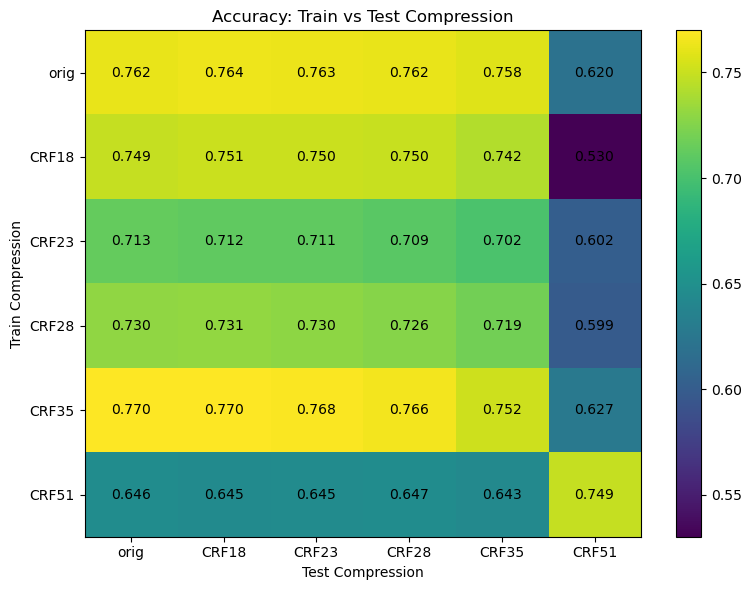

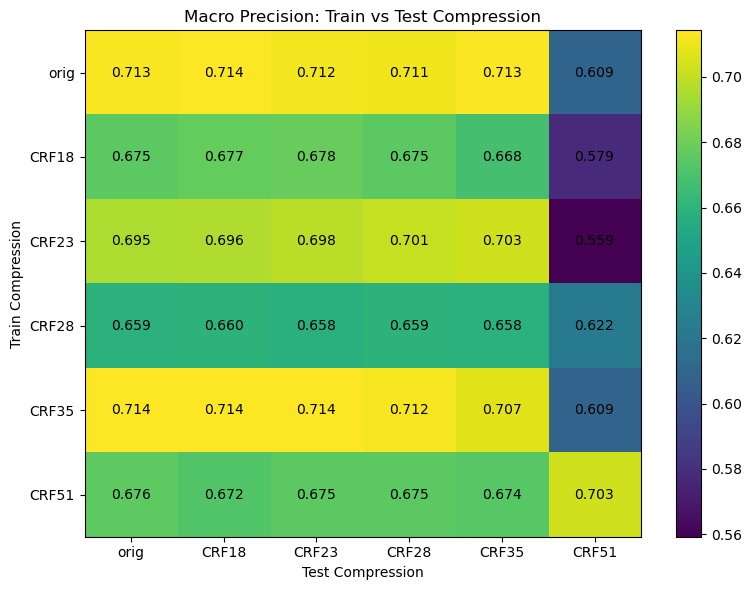

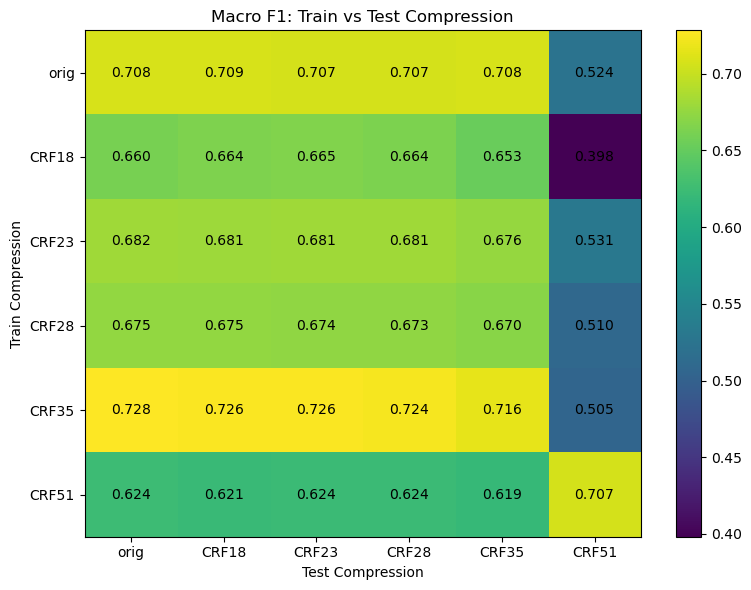

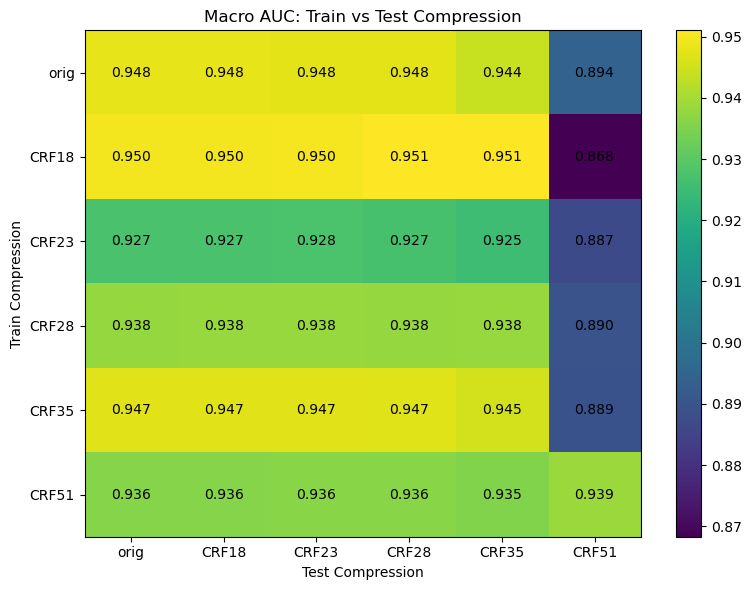

In [17]:
# ============================================================
# 17. Heatmap helper
# ============================================================
def plot_heatmap(df, title, save_name, vmin=None, vmax=None):
    arr = df.values

    plt.figure(figsize=(8, 6))
    im = plt.imshow(arr, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(im)

    plt.xticks(range(len(df.columns)), df.columns)
    plt.yticks(range(len(df.index)), df.index)
    plt.xlabel("Test Compression")
    plt.ylabel("Train Compression")
    plt.title(title)

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / save_name, dpi=200)
    plt.show()

plot_heatmap(pivot_acc, "Accuracy: Train vs Test Compression", "heatmap_accuracy.png")
plot_heatmap(pivot_prec, "Macro Precision: Train vs Test Compression", "heatmap_precision.png")
plot_heatmap(pivot_f1, "Macro F1: Train vs Test Compression", "heatmap_f1.png")
plot_heatmap(pivot_auc, "Macro AUC: Train vs Test Compression", "heatmap_auc.png")

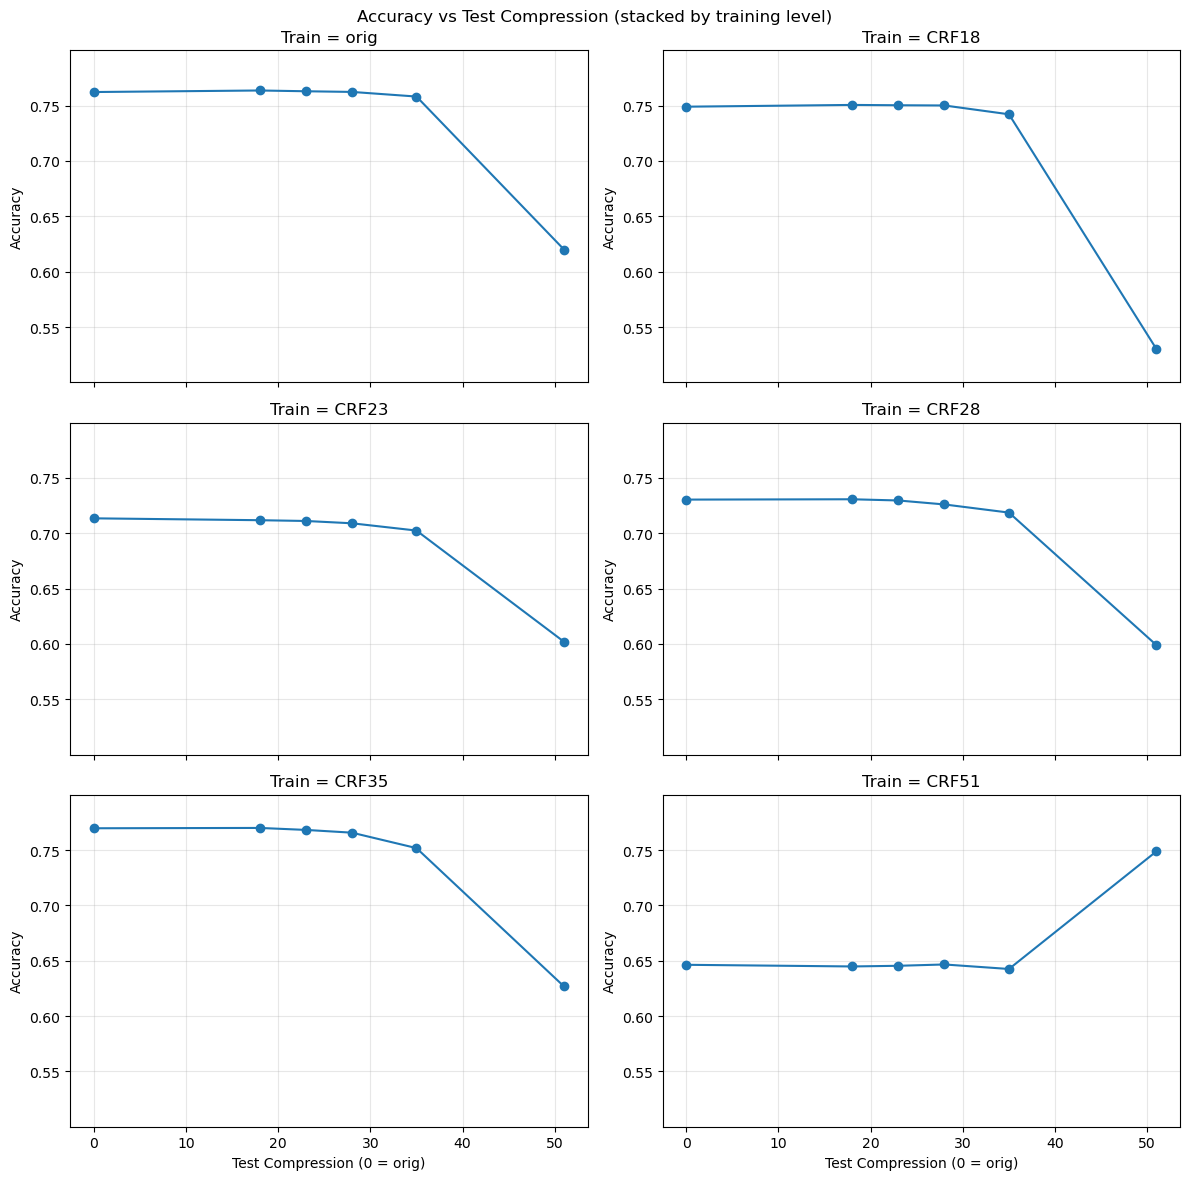

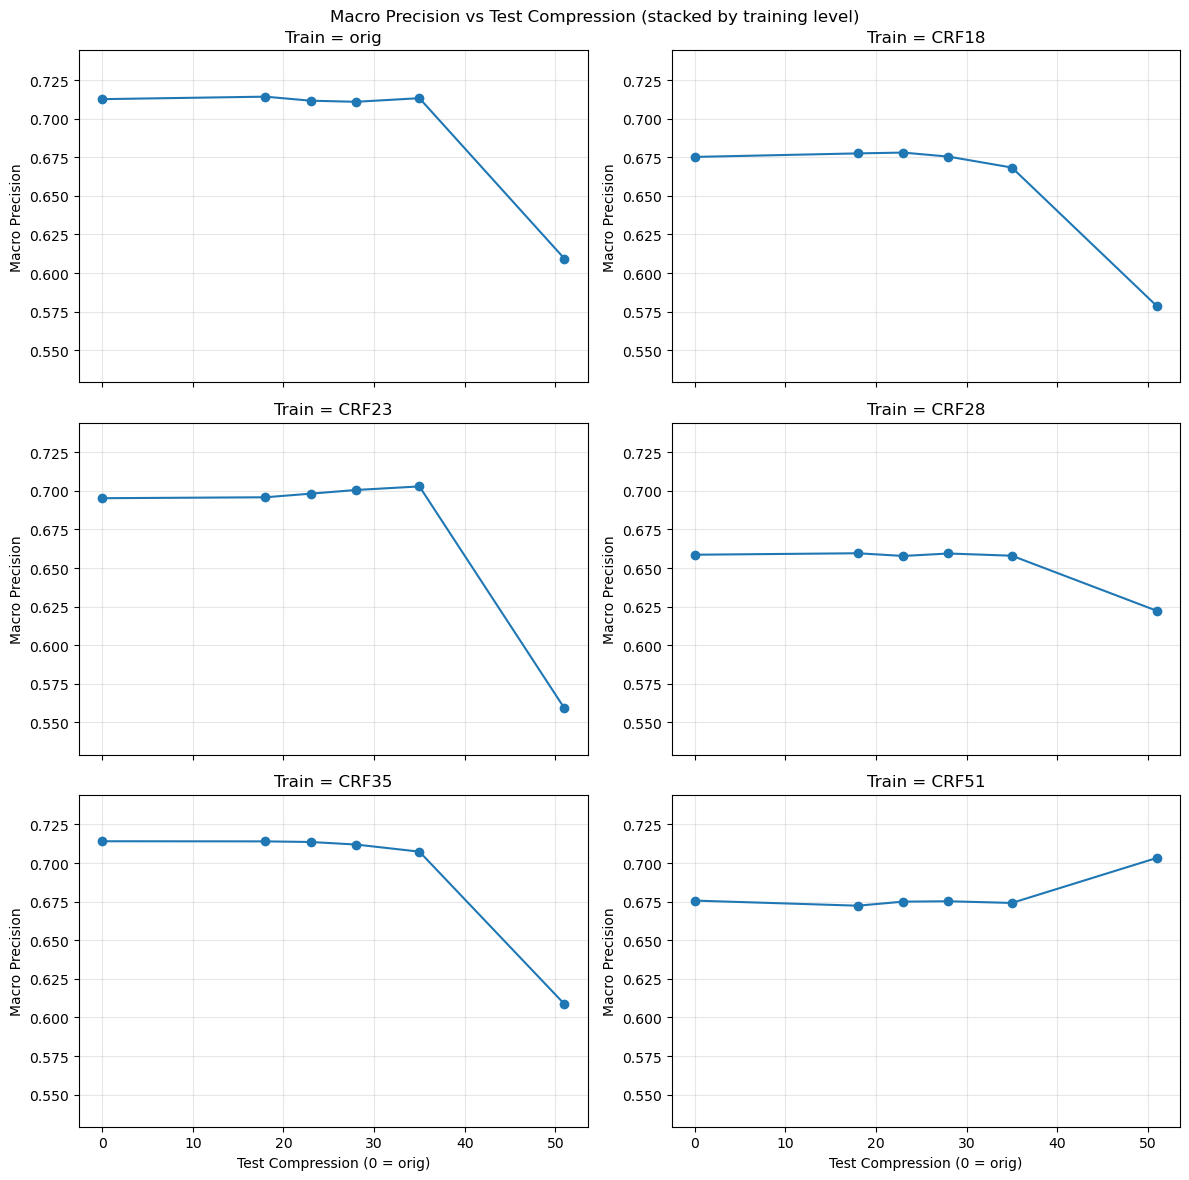

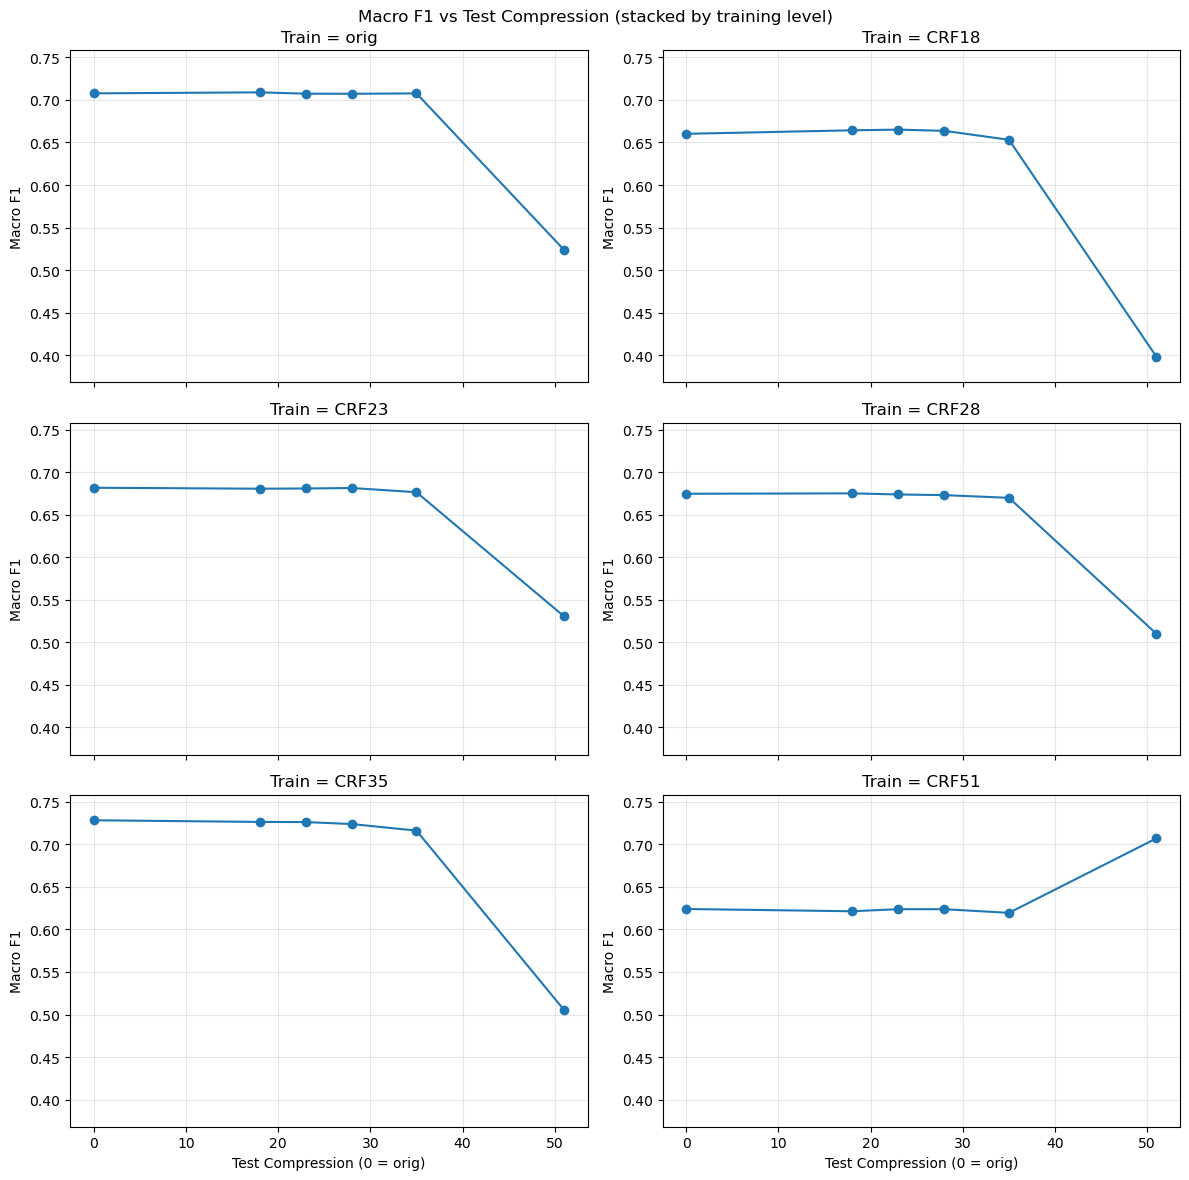

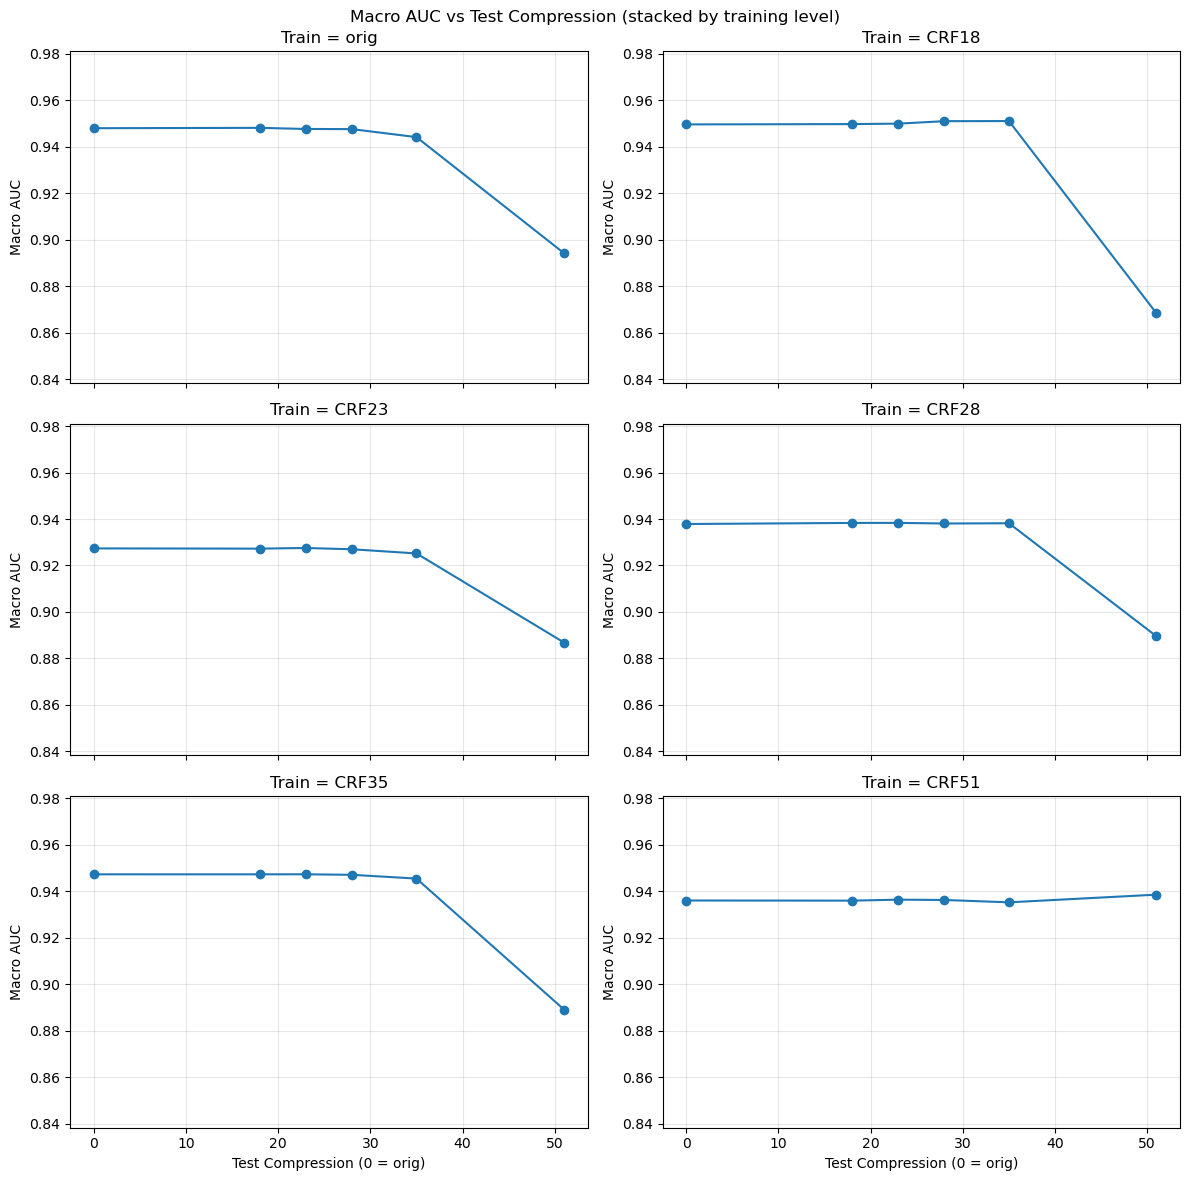

In [18]:
# ============================================================
# 18. Stacked metric-vs-test-compression plots
# ============================================================
def stacked_metric_plot(metric_name, y_label, save_name):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
    axes = axes.flatten()

    y_min = results_df[metric_name].min()
    y_max = results_df[metric_name].max()
    pad = 0.03

    for ax, train_level in zip(axes, LEVELS):
        subset = results_df[results_df["train_level"] == train_level].copy()
        subset["x"] = subset["test_level"].map(LEVEL_TO_X)
        subset = subset.sort_values("x")

        ax.plot(subset["x"], subset[metric_name], marker="o")
        ax.set_title(f"Train = {train_level}")
        ax.set_ylabel(y_label)
        ax.set_ylim(max(0, y_min - pad), min(1.0, y_max + pad))
        ax.grid(True, alpha=0.3)

    for ax in axes[-2:]:
        ax.set_xlabel("Test Compression (0 = orig)")

    plt.suptitle(f"{y_label} vs Test Compression (stacked by training level)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / save_name, dpi=200)
    plt.show()

stacked_metric_plot("accuracy", "Accuracy", "stacked_accuracy_vs_test_compression.png")
stacked_metric_plot("precision_macro", "Macro Precision", "stacked_precision_vs_test_compression.png")
stacked_metric_plot("f1_macro", "Macro F1", "stacked_f1_vs_test_compression.png")
stacked_metric_plot("auc_macro_ovr", "Macro AUC", "stacked_auc_vs_test_compression.png")

In [19]:
# ============================================================
# 19. Diagonal metrics
# ============================================================
diagonal_rows = []
for level in LEVELS:
    row = results_df[
        (results_df["train_level"] == level) &
        (results_df["test_level"] == level)
    ].iloc[0].to_dict()
    row["x"] = LEVEL_TO_X[level]
    diagonal_rows.append(row)

diagonal_df = pd.DataFrame(diagonal_rows).sort_values("x").reset_index(drop=True)
diagonal_df.to_csv(METRICS_DIR / "diagonal_same_compression_metrics.csv", index=False)
diagonal_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss,x
0,orig,orig,0.762293,0.712617,0.711836,0.707744,0.947949,1.167103,0
1,CRF18,CRF18,0.750647,0.677494,0.692537,0.664325,0.949716,0.877287,18
2,CRF23,CRF23,0.711029,0.698159,0.689775,0.680792,0.927532,1.378388,23
3,CRF28,CRF28,0.725961,0.659421,0.728770,0.672974,0.938065,1.241319,28
4,CRF35,CRF35,0.751742,0.707367,0.731452,0.716099,0.945482,1.201916,35
5,CRF51,CRF51,0.748855,0.703306,0.725502,0.707060,0.938572,1.036627,51


In [20]:
# ============================================================
# 19. Diagonal metrics
# ============================================================
diagonal_rows = []
for level in LEVELS:
    row = results_df[
        (results_df["train_level"] == level) &
        (results_df["test_level"] == level)
    ].iloc[0].to_dict()
    row["x"] = LEVEL_TO_X[level]
    diagonal_rows.append(row)

diagonal_df = pd.DataFrame(diagonal_rows).sort_values("x").reset_index(drop=True)
diagonal_df.to_csv(METRICS_DIR / "diagonal_same_compression_metrics.csv", index=False)
diagonal_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss,x
0,orig,orig,0.762293,0.712617,0.711836,0.707744,0.947949,1.167103,0
1,CRF18,CRF18,0.750647,0.677494,0.692537,0.664325,0.949716,0.877287,18
2,CRF23,CRF23,0.711029,0.698159,0.689775,0.680792,0.927532,1.378388,23
3,CRF28,CRF28,0.725961,0.659421,0.728770,0.672974,0.938065,1.241319,28
4,CRF35,CRF35,0.751742,0.707367,0.731452,0.716099,0.945482,1.201916,35
5,CRF51,CRF51,0.748855,0.703306,0.725502,0.707060,0.938572,1.036627,51


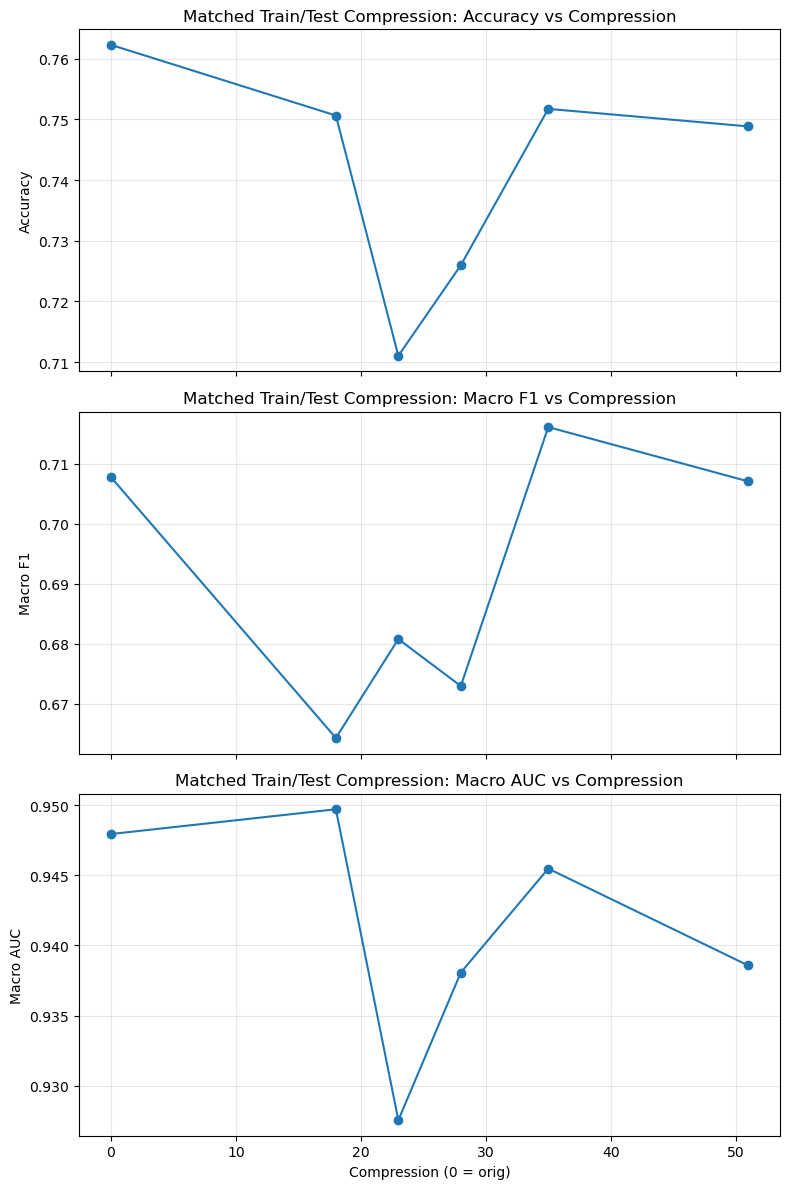

In [21]:
# ============================================================
# 20. Diagonal plots
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(diagonal_df["x"], diagonal_df["accuracy"], marker="o")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Matched Train/Test Compression: Accuracy vs Compression")
axes[0].grid(True, alpha=0.3)

axes[1].plot(diagonal_df["x"], diagonal_df["f1_macro"], marker="o")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Matched Train/Test Compression: Macro F1 vs Compression")
axes[1].grid(True, alpha=0.3)

axes[2].plot(diagonal_df["x"], diagonal_df["auc_macro_ovr"], marker="o")
axes[2].set_ylabel("Macro AUC")
axes[2].set_xlabel("Compression (0 = orig)")
axes[2].set_title("Matched Train/Test Compression: Macro AUC vs Compression")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "diagonal_metrics_vs_compression.png", dpi=200)
plt.show()

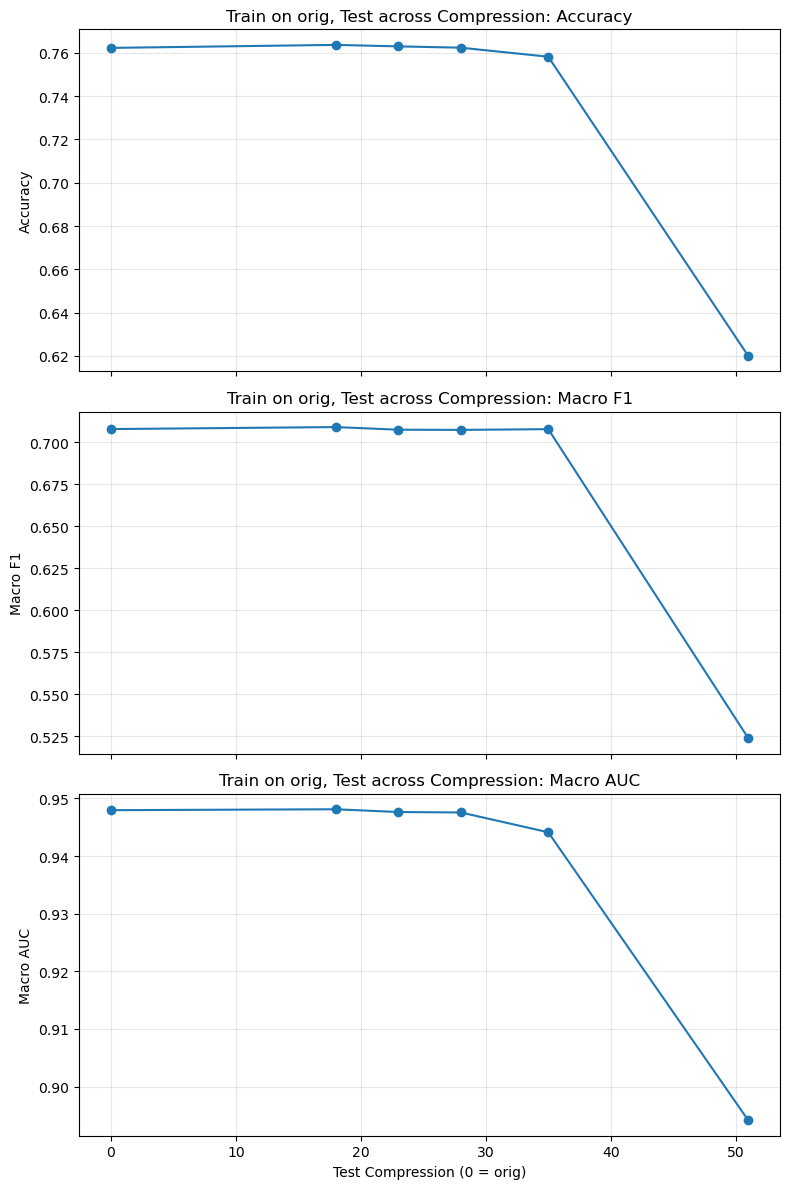

In [22]:
# ============================================================
# 21. Orig-trained curves
# ============================================================
orig_row_df = results_df[results_df["train_level"] == "orig"].copy()
orig_row_df["x"] = orig_row_df["test_level"].map(LEVEL_TO_X)
orig_row_df = orig_row_df.sort_values("x").reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(orig_row_df["x"], orig_row_df["accuracy"], marker="o")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train on orig, Test across Compression: Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(orig_row_df["x"], orig_row_df["f1_macro"], marker="o")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Train on orig, Test across Compression: Macro F1")
axes[1].grid(True, alpha=0.3)

axes[2].plot(orig_row_df["x"], orig_row_df["auc_macro_ovr"], marker="o")
axes[2].set_ylabel("Macro AUC")
axes[2].set_xlabel("Test Compression (0 = orig)")
axes[2].set_title("Train on orig, Test across Compression: Macro AUC")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "orig_trained_metrics_vs_test_compression.png", dpi=200)
plt.show()

In [23]:
# ============================================================
# 22. Build per-phase results table
# ============================================================
phase_rows = []
for (train_level, test_level), m in all_results.items():
    for phase_name, phase_f1 in m["per_class_f1"].items():
        phase_rows.append({
            "train_level": train_level,
            "test_level": test_level,
            "phase_name": phase_name,
            "phase_f1": phase_f1,
            "x": LEVEL_TO_X[test_level],
        })

phase_df = pd.DataFrame(phase_rows)
phase_df.to_csv(METRICS_DIR / "per_phase_f1_cross_compression.csv", index=False)
phase_df.head()

,train_level,test_level,phase_name,phase_f1,x
0,orig,orig,Preparation,0.635930,0
1,orig,orig,CalotTriangleDissection,0.828085,0
2,orig,orig,ClippingCutting,0.750311,0
3,orig,orig,GallbladderDissection,0.718074,0
4,orig,orig,GallbladderPackaging,0.683516,0


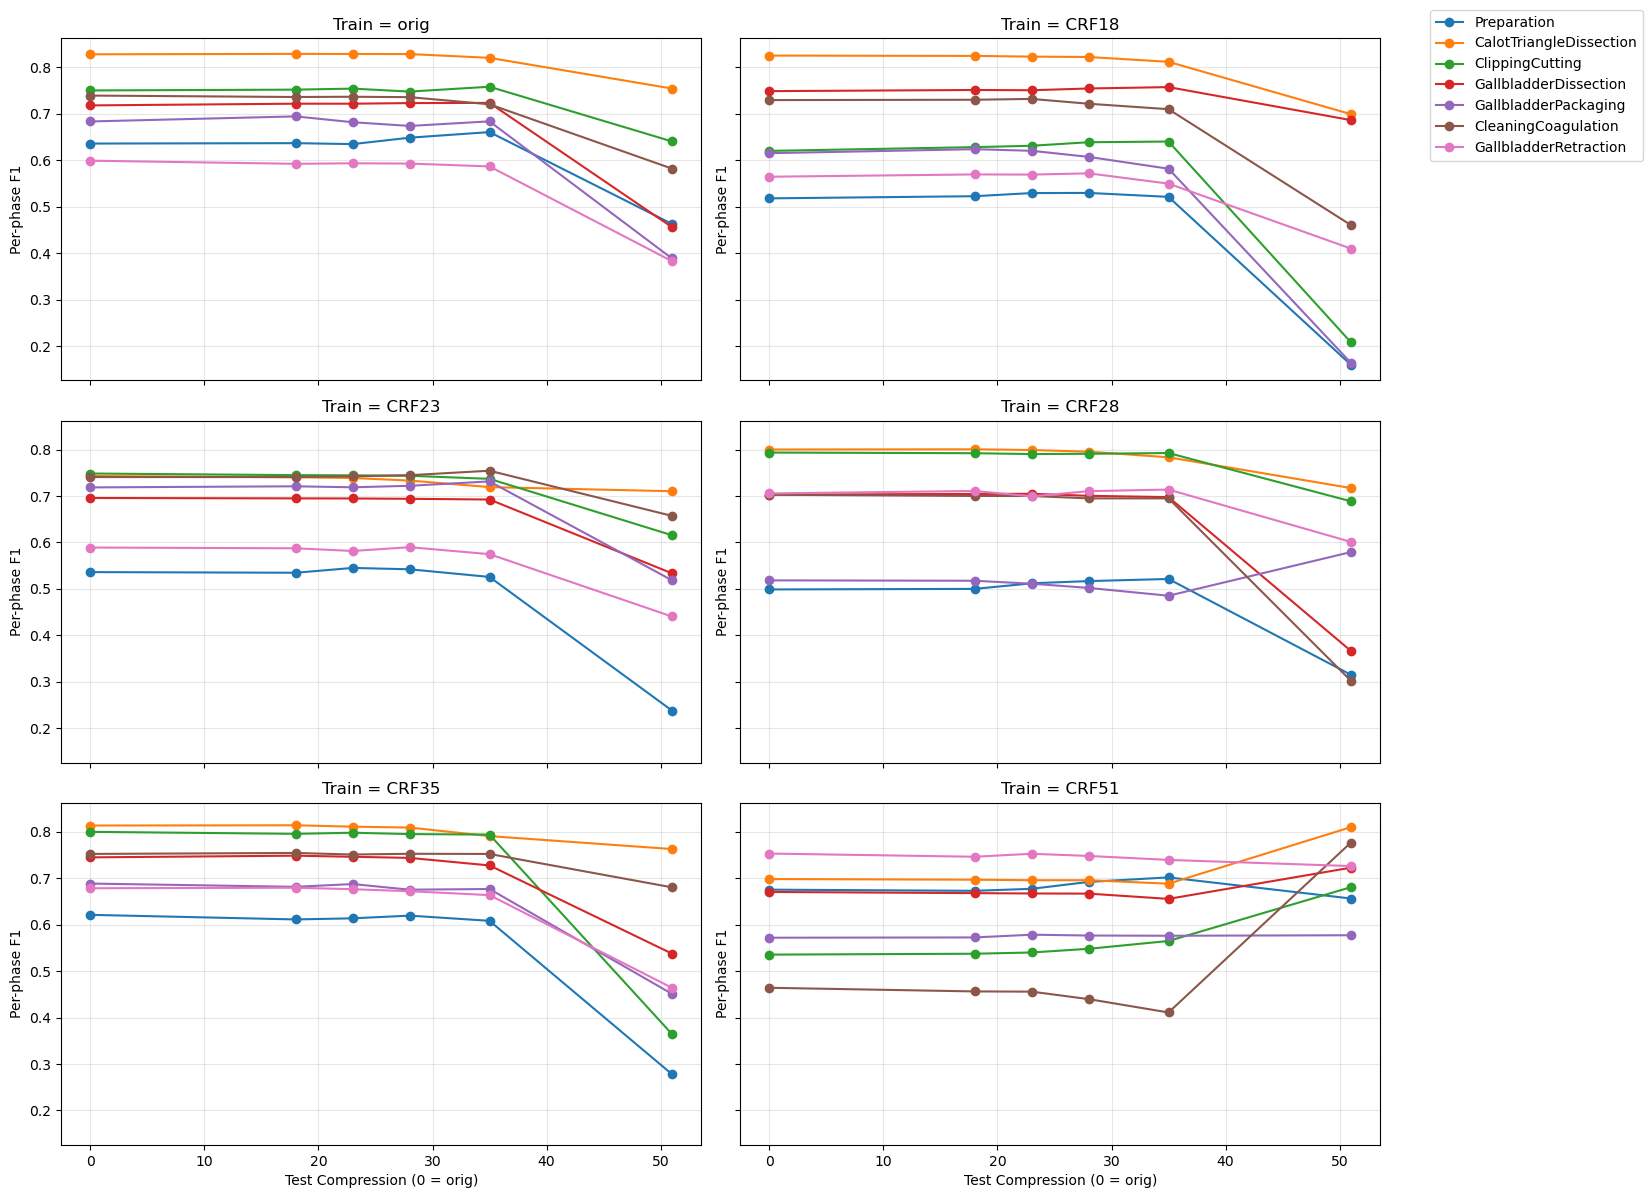

In [24]:
# ============================================================
# 23. Per-phase stacked plot
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, train_level in zip(axes, LEVELS):
    subset = phase_df[phase_df["train_level"] == train_level].copy()

    for phase_name in PHASE_MAP.keys():
        s = subset[subset["phase_name"] == phase_name].sort_values("x")
        ax.plot(s["x"], s["phase_f1"], marker="o", label=phase_name)

    ax.set_title(f"Train = {train_level}")
    ax.set_ylabel("Per-phase F1")
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel("Test Compression (0 = orig)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "stacked_per_phase_f1_vs_test_compression.png", dpi=200)
plt.show()

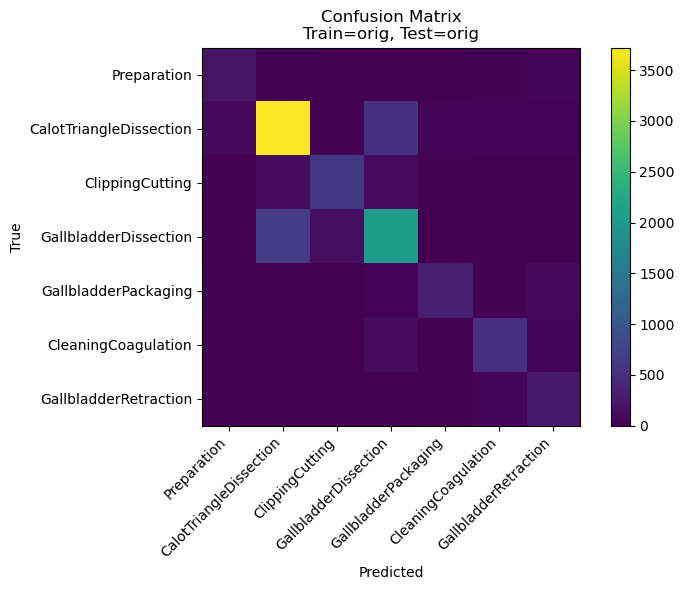

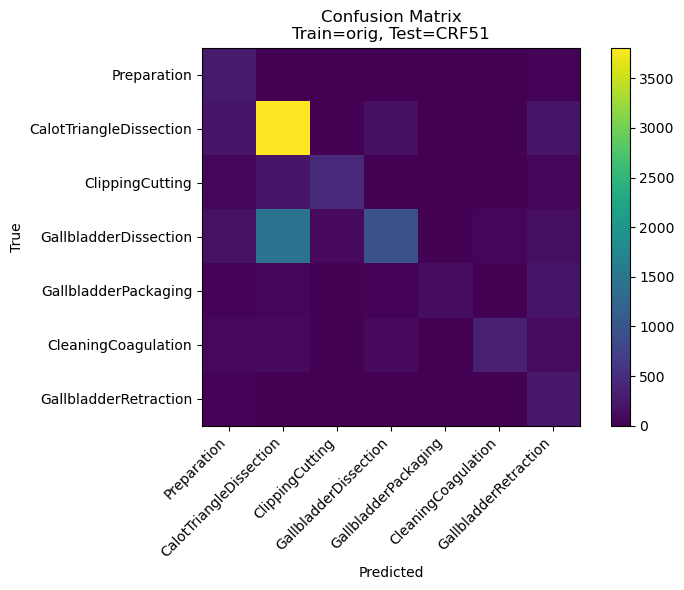

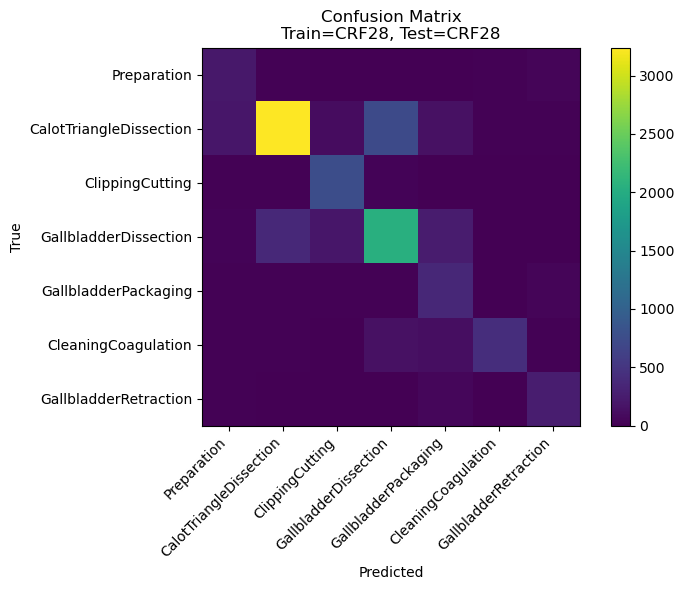

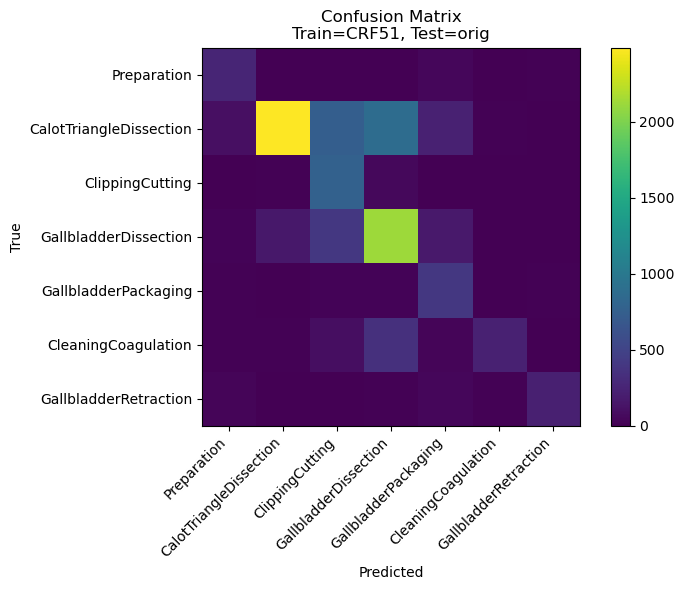

In [25]:
# ============================================================
# 24. Confusion matrix helper
# ============================================================
def plot_confusion_for_pair(train_level, test_level):
    pred_df = all_pred_tables[(train_level, test_level)]
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix\nTrain={train_level}, Test={test_level}")
    plt.colorbar()

    ticks = np.arange(NUM_CLASSES)
    names = [ID_TO_PHASE[i] for i in range(NUM_CLASSES)]
    plt.xticks(ticks, names, rotation=45, ha="right")
    plt.yticks(ticks, names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"confusion_train_{train_level}__test_{test_level}.png", dpi=200)
    plt.show()

selected_pairs = [
    ("orig", "orig"),
    ("orig", "CRF51"),
    ("CRF28", "CRF28"),
    ("CRF51", "orig"),
]

for pair in selected_pairs:
    plot_confusion_for_pair(*pair)

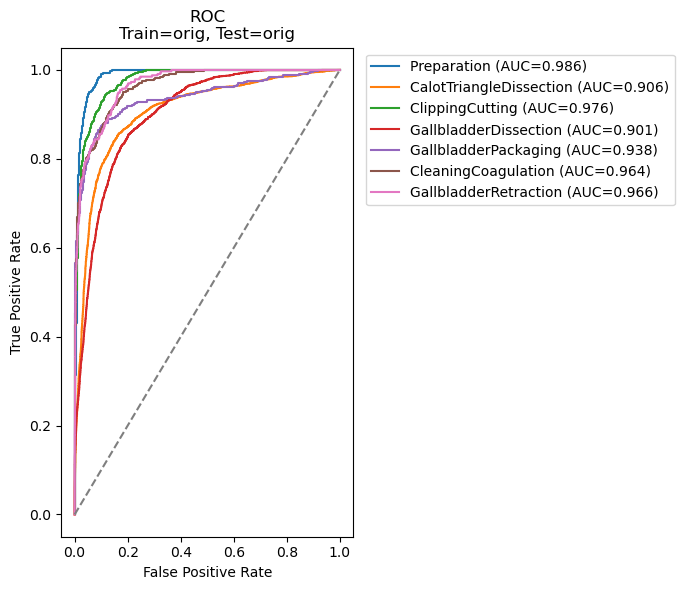

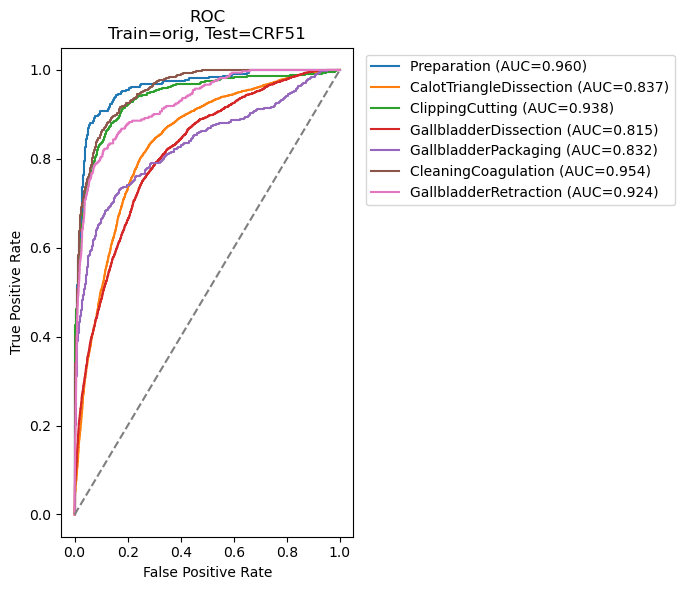

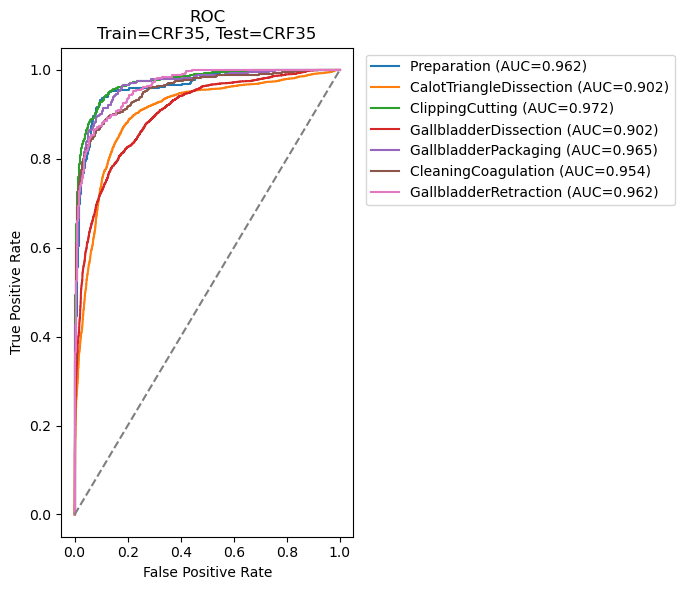

In [33]:
# ============================================================
# 25. ROC helper
# ============================================================
def plot_roc_for_pair(train_level, test_level):
    pred_df = all_pred_tables[(train_level, test_level)]
    y_true = pred_df["y_true"].values
    y_prob = pred_df[[f"prob_{ID_TO_PHASE[i]}" for i in range(NUM_CLASSES)]].values
    y_true_oh = np.eye(NUM_CLASSES)[y_true]

    plt.figure(figsize=(7, 6))

    for c in range(NUM_CLASSES):
        try:
            fpr, tpr, _ = roc_curve(y_true_oh[:, c], y_prob[:, c])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{ID_TO_PHASE[c]} (AUC={roc_auc:.3f})")
        except Exception:
            pass

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC\nTrain={train_level}, Test={test_level}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"roc_train_{train_level}__test_{test_level}.png", dpi=200)
    plt.show()

for pair in [("orig", "orig"), ("orig", "CRF51"), ("CRF35", "CRF35")]:
    plot_roc_for_pair(*pair)

## Grad-CAM on the last frame of each clip

In [27]:
# ============================================================
# 26. Sequence Grad-CAM
# ============================================================
class SequenceGradCAM:
    def __init__(self, model, target_layer, clip_len=CLIP_LEN):
        self.model = model
        self.target_layer = target_layer
        self.clip_len = clip_len
        self.activations = None
        self.gradients = None
        self.handles = []

        self.handles.append(target_layer.register_forward_hook(self._forward_hook))
        self.handles.append(target_layer.register_full_backward_hook(self._backward_hook))

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        for h in self.handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        acts = self.activations
        grads = self.gradients

        B = x.shape[0]
        T = x.shape[1]
        C = acts.shape[1]
        H = acts.shape[2]
        W = acts.shape[3]

        acts = acts.view(B, T, C, H, W)
        grads = grads.view(B, T, C, H, W)

        acts_last = acts[0, -1]
        grads_last = grads[0, -1]

        weights = grads_last.mean(dim=(1, 2))

        cam = torch.zeros(acts_last.shape[1:], device=acts_last.device)
        for c, w in enumerate(weights):
            cam += w * acts_last[c]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy(), class_idx

In [28]:
# ============================================================
# 27. Grad-CAM helpers
# ============================================================
def load_sequence_clip_from_prediction_row(pred_row, test_level):
    test_base = metadata[test_level][metadata[test_level]["split"] == "test"].reset_index(drop=True)
    seq_df = build_sequence_samples(test_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)

    row = seq_df[
        (seq_df["video"] == pred_row["video"]) &
        (seq_df["center_second_idx"].astype(int) == int(pred_row["center_second_idx"]))
    ].iloc[0]

    frames = []
    for p in row["clip_image_paths"]:
        img = Image.open(p).convert("RGB")
        frames.append(eval_tfms(img))
    clip = torch.stack(frames, dim=0).unsqueeze(0).to(DEVICE)

    last_frame_pil = Image.open(row["clip_image_paths"][-1]).convert("RGB")
    return last_frame_pil, clip


def get_prediction_row(train_level, test_level, video, center_second_idx):
    df = all_pred_tables[(train_level, test_level)]
    row = df[
        (df["video"] == video) &
        (df["center_second_idx"].astype(int) == int(center_second_idx))
    ]
    if len(row) == 0:
        return None
    return row.iloc[0]

In [29]:
# ============================================================
# 28. Load one trained model for Grad-CAM
# ============================================================
GRADCAM_TRAIN_LEVEL = "orig"

gradcam_model = ResNet18Transformer().to(DEVICE)
gradcam_ckpt = torch.load(CHECKPOINT_DIR / f"best_resnet18_transformer_train_{GRADCAM_TRAIN_LEVEL}.pth", map_location=DEVICE)
gradcam_model.load_state_dict(gradcam_ckpt["model_state_dict"])
gradcam_model.eval()

gradcam = SequenceGradCAM(gradcam_model, gradcam_model.encoder[-1], clip_len=CLIP_LEN)

print("Loaded Grad-CAM model trained on:", GRADCAM_TRAIN_LEVEL)

Loaded Grad-CAM model trained on: orig


In [30]:
# ============================================================
# 29. Grad-CAM comparison function
# ============================================================
def show_gradcam_comparison(train_level, video, center_second_idx, test_levels=("orig", "CRF18", "CRF28", "CRF51"), use_pred_class=True):
    n = len(test_levels)
    plt.figure(figsize=(4 * n, 8))

    for i, test_level in enumerate(test_levels, start=1):
        row = get_prediction_row(train_level, test_level, video, center_second_idx)
        if row is None:
            continue

        pil_img, clip = load_sequence_clip_from_prediction_row(row, test_level)
        class_idx = int(row["y_pred"]) if use_pred_class else int(row["y_true"])
        cam, used_class = gradcam(clip, class_idx=class_idx)

        raw_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))

        plt.subplot(2, n, i)
        plt.imshow(raw_img)
        plt.axis("off")
        plt.title(f"Test={test_level}\nTrue={row['y_true_name']}\nPred={row['y_pred_name']}")

        plt.subplot(2, n, i + n)
        plt.imshow(raw_img)
        plt.imshow(cam, alpha=0.4)
        plt.axis("off")
        plt.title(f"Grad-CAM ({ID_TO_PHASE[used_class]})")

    plt.suptitle(f"Train={train_level} | {video} | center_second_idx={center_second_idx}")
    plt.tight_layout()

    save_path = GRADCAM_DIR / f"gradcam_train_{train_level}__{video}_sec{center_second_idx}.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)

In [31]:
# ============================================================
# 30. Pick candidate orig-orig correct examples
# ============================================================
orig_orig_correct = all_pred_tables[("orig", "orig")].copy()
orig_orig_correct = orig_orig_correct[orig_orig_correct["y_true"] == orig_orig_correct["y_pred"]]

orig_orig_correct[["video", "center_second_idx", "y_true_name", "y_pred_name"]].head(20)

,video,center_second_idx,y_true_name,y_pred_name
0,video16,tensor(7),Preparation,Preparation
1,video16,tensor(8),Preparation,Preparation
2,video16,tensor(9),Preparation,Preparation
3,video16,tensor(10),Preparation,Preparation
15,video16,tensor(22),Preparation,Preparation
17,video16,tensor(24),Preparation,Preparation
18,video16,tensor(25),Preparation,Preparation
19,video16,tensor(26),Preparation,Preparation
20,video16,tensor(27),Preparation,Preparation
21,video16,tensor(28),Preparation,Preparation


In [32]:
# ============================================================
# 31. Example Grad-CAM call
# ============================================================
# Replace with a real example from the table above
# show_gradcam_comparison(train_level="orig", video="video16", center_second_idx=100)